# Scrap chocolate bar ratings

We have a website that has over 1700 reviews of chocolate bars from all around the world:

In [2]:
site = "https://content.codecademy.com/courses/beautifulsoup/cacao/index.html"

The rating scale is from 1-5, as described in <a href="http://flavorsofcacao.com/review_guide.html">this review guide</a>. A `1` is "unpleasant" chocolate, while a `5` is a bar that transcends "beyond the ordinary limits".

Some questions we thought about:
 - Where are the best cocao beans grown?
 - Which countries produce the highest-rated bars?
 - What's the relationship between cocao solids percentage and rating?

## Make Some Chocolate Soup

In [3]:
import requests

choco = requests.get(site)

In [7]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(choco.content, "html.parser")

In [4]:
soup

<!DOCTYPE html>

<html lang="en">
<head>
<meta charset="utf-8"/>
<style>
         #cacaoTable {
         border-collapse: collapse;
         border: 2px black solid;
         font: 12px sans-serif;
         }
         #cacaoTable td {
         border: 1px black solid;
         padding: 5px;
         }
         #infoContainer {
         margin-bottom: 10px;
         display: inline-block;
         margin-right: 10px;
         }
         #chocolate {
         width: 300px;
         }
         #picContainer {
         display: inline;
         }
      </style>
</head>
<body>
<!-- <script src="http://d3js.org/d3.v3.min.js"></script> -->
<div id="banner">
<h1>Cacao Ratings</h1>
</div>
<div id="infoContainer">
<table class="infoTable">
<tr>
<td>Compiled ratings of over 1700 Chocolate bars</td>
</tr>
<tr>
<td>Ratings are from 1-5</td>
</tr>
</table>
</div>
<div id="picContainer">
<img id="chocolate" src="chocolate.jpg"/>
</div>
<table id="cacaoTable">
<tr>
<td class="Company">Company 
       

## How are ratings distributed?

first, put all of the ratings into a list.

In [8]:
rating_tags = soup.select(".Rating")

In [9]:
rating_tags

[<td class="Rating">Rating</td>,
 <td class="Rating">3.75</td>,
 <td class="Rating">2.75</td>,
 <td class="Rating">3</td>,
 <td class="Rating">3.5</td>,
 <td class="Rating">3.5</td>,
 <td class="Rating">2.75</td>,
 <td class="Rating">3.5</td>,
 <td class="Rating">3.5</td>,
 <td class="Rating">3.75</td>,
 <td class="Rating">4</td>,
 <td class="Rating">2.75</td>,
 <td class="Rating">3</td>,
 <td class="Rating">3.25</td>,
 <td class="Rating">3.75</td>,
 <td class="Rating">2.75</td>,
 <td class="Rating">3</td>,
 <td class="Rating">3.25</td>,
 <td class="Rating">4</td>,
 <td class="Rating">3.25</td>,
 <td class="Rating">3.5</td>,
 <td class="Rating">4</td>,
 <td class="Rating">3.5</td>,
 <td class="Rating">3.75</td>,
 <td class="Rating">3.75</td>,
 <td class="Rating">3.75</td>,
 <td class="Rating">2.75</td>,
 <td class="Rating">3.25</td>,
 <td class="Rating">3.5</td>,
 <td class="Rating">3.5</td>,
 <td class="Rating">2.75</td>,
 <td class="Rating">3</td>,
 <td class="Rating">3</td>,
 <td cl

In [9]:
ratings = []

for r in rating_tags[1:]:
    r_text = r.get_text()
    r_score = float(r_text)
    ratings.append(r_score)
ratings

[3.75,
 2.75,
 3.0,
 3.5,
 3.5,
 2.75,
 3.5,
 3.5,
 3.75,
 4.0,
 2.75,
 3.0,
 3.25,
 3.75,
 2.75,
 3.0,
 3.25,
 4.0,
 3.25,
 3.5,
 4.0,
 3.5,
 3.75,
 3.75,
 3.75,
 2.75,
 3.25,
 3.5,
 3.5,
 2.75,
 3.0,
 3.0,
 3.75,
 2.75,
 2.75,
 2.75,
 2.75,
 3.0,
 2.5,
 2.5,
 3.5,
 3.5,
 3.5,
 3.5,
 2.75,
 3.0,
 2.5,
 2.5,
 2.75,
 2.5,
 3.0,
 3.25,
 3.0,
 3.25,
 4.0,
 3.75,
 4.0,
 3.0,
 3.0,
 2.75,
 3.5,
 3.0,
 3.75,
 3.0,
 2.75,
 2.75,
 3.0,
 3.25,
 3.5,
 3.0,
 3.25,
 3.25,
 3.25,
 3.25,
 3.5,
 3.75,
 4.0,
 4.0,
 5.0,
 3.0,
 3.0,
 3.5,
 3.75,
 4.0,
 3.5,
 3.5,
 5.0,
 4.0,
 3.25,
 2.75,
 3.75,
 3.75,
 4.0,
 3.0,
 3.5,
 3.0,
 2.5,
 2.75,
 3.0,
 3.5,
 3.75,
 3.5,
 3.25,
 3.25,
 3.5,
 3.75,
 3.5,
 4.0,
 4.0,
 3.75,
 3.25,
 3.25,
 3.5,
 3.5,
 3.75,
 3.5,
 3.75,
 4.0,
 2.75,
 3.25,
 3.5,
 3.25,
 3.75,
 4.0,
 2.75,
 1.75,
 3.75,
 3.25,
 3.25,
 3.5,
 2.5,
 2.75,
 1.75,
 3.0,
 3.0,
 3.25,
 3.75,
 2.75,
 3.75,
 3.75,
 3.75,
 3.75,
 2.5,
 3.0,
 3.25,
 3.5,
 3.0,
 2.5,
 2.5,
 2.75,
 3.5,
 3.5,
 4.0,
 3.25,
 3.5

Text(0.5, 0, 'Rating')

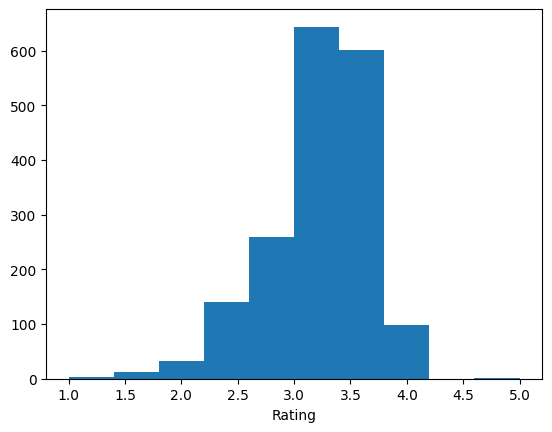

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.hist(ratings)
plt.xlabel('Rating')

## Which chocolatier makes the best chocolate?

We want to find the 10 most highly rated chocolatiers. One way to do this is to make a DataFrame that has the chocolate companies in one column, and the ratings in another. Then, we can do a `groupby` to find the ones with the highest average rating.

First, find all tags on the webpage that contain the company names.

In [19]:
company_tags = soup.select(".Company")
company_tags

[<td class="Company">Company 
                (Maker-if known)
             </td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">A. Morin</td>,
 <td class="Company">Acalli</td>,
 <td class="Company">Acalli</td>,
 <td class="Company">

In [17]:
companies = []

Loop through the tags containing the company names, and add the text from each tag to the list you just created.

In [20]:
for c in company_tags[1:]:
    companies.append(c.get_text())
companies

['A. Morin',
 'A. Morin',
 'A. Morin',
 'A. Morin',
 'A. Morin',
 'A. Morin',
 'A. Morin',
 'A. Morin',
 'A. Morin',
 'A. Morin',
 'A. Morin',
 'A. Morin',
 'A. Morin',
 'A. Morin',
 'A. Morin',
 'A. Morin',
 'A. Morin',
 'A. Morin',
 'A. Morin',
 'A. Morin',
 'A. Morin',
 'A. Morin',
 'A. Morin',
 'Acalli',
 'Acalli',
 'Adi',
 'Adi',
 'Adi',
 'Adi',
 'Aequare (Gianduja)',
 'Aequare (Gianduja)',
 'Ah Cacao',
 "Akesson's (Pralus)",
 "Akesson's (Pralus)",
 "Akesson's (Pralus)",
 'Alain Ducasse',
 'Alain Ducasse',
 'Alain Ducasse',
 'Alain Ducasse',
 'Alain Ducasse',
 'Alexandre',
 'Alexandre',
 'Alexandre',
 'Alexandre',
 'Altus aka Cao Artisan',
 'Altus aka Cao Artisan',
 'Altus aka Cao Artisan',
 'Altus aka Cao Artisan',
 'Altus aka Cao Artisan',
 'Altus aka Cao Artisan',
 'Altus aka Cao Artisan',
 'Altus aka Cao Artisan',
 'Altus aka Cao Artisan',
 'Altus aka Cao Artisan',
 'Amano',
 'Amano',
 'Amano',
 'Amano',
 'Amano',
 'Amano',
 'Amano',
 'Amano',
 'Amano',
 'Amatller (Simon Coll)

In [21]:
import pandas as pd

company_rating = {'Company': companies, 'Ratings': ratings}
df = pd.DataFrame.from_dict(company_rating)

In [24]:
mn_ratings = df.groupby('Company').Ratings.mean()
ten_best = mn_ratings.nlargest(10)
ten_best

Company
Tobago Estate (Pralus)                  4.000000
Heirloom Cacao Preservation (Zokoko)    3.875000
Ocelot                                  3.875000
Amedei                                  3.846154
Matale                                  3.812500
Patric                                  3.791667
Idilio (Felchlin)                       3.775000
Acalli                                  3.750000
Chocola'te                              3.750000
Christopher Morel (Felchlin)            3.750000
Name: Ratings, dtype: float64

## Is more cacao better?

We want to see if the chocolate experts tend to rate chocolate bars with higher levels of cacoa to be better than those with lower levels of cacoa.

In [25]:
cocoa_tags = soup.select(".CocoaPercent")
cocoa_tags

[<td class="CocoaPercent">Cocoa
                Percent
             </td>,
 <td class="CocoaPercent">63%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent">63%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent">63%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent">70%</td>,
 <td class="CocoaPercent

In [27]:
cocoa_perc = []
for p in cocoa_tags[1:]:
    p_text = p.get_text().strip('%')
    p_per = float(p_text)
    cocoa_perc.append(p_per)
cocoa_perc

[63.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 63.0,
 70.0,
 63.0,
 70.0,
 70.0,
 60.0,
 80.0,
 88.0,
 72.0,
 55.0,
 70.0,
 70.0,
 75.0,
 75.0,
 75.0,
 65.0,
 75.0,
 75.0,
 75.0,
 75.0,
 70.0,
 70.0,
 70.0,
 70.0,
 60.0,
 60.0,
 60.0,
 60.0,
 60.0,
 60.0,
 60.0,
 80.0,
 60.0,
 60.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 85.0,
 85.0,
 72.0,
 73.0,
 64.0,
 66.0,
 75.0,
 63.0,
 70.0,
 68.0,
 70.0,
 70.0,
 75.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 63.0,
 70.0,
 66.0,
 75.0,
 85.0,
 50.0,
 75.0,
 60.0,
 75.0,
 75.0,
 75.0,
 72.0,
 75.0,
 75.0,
 70.0,
 70.0,
 73.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 70.0,
 73.0,
 70.0,
 68.0,
 70.0,
 70.0,
 70.0,
 70.0,
 75.0,
 70.0,
 75.0,
 72.0,
 72.0,
 72.0,
 72.0,
 100.0,
 72.0,
 72.0,
 72.0,
 72.0,
 75.0,
 72.0,
 72.0,
 80.0,
 75.0,
 72.0,
 72.0,
 72.0,
 68.0,
 72.0,
 70.0,
 77.0,
 75.0

In [29]:
cocoa = {"Company": companies, "Ratings": ratings, "CocoaPercentage": cocoa_perc}
cocoa_df = pd.DataFrame.from_dict(cocoa)

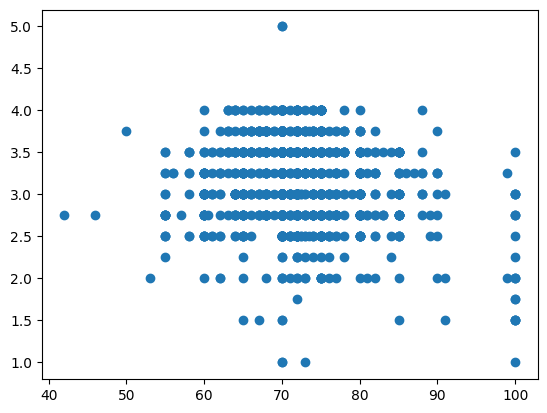

In [32]:
plt.scatter(cocoa_df.CocoaPercentage, cocoa_df.Ratings)

use some numpy commands to draw a line of best-fit over the scatterplot.

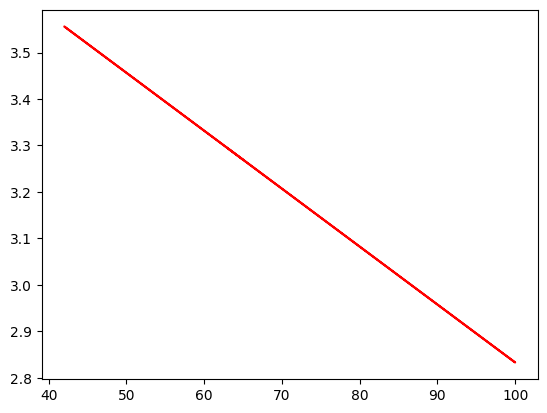

In [33]:
import numpy as np

z = np.polyfit(cocoa_df.CocoaPercentage, cocoa_df.Ratings, 1)
line_function = np.poly1d(z)
plt.plot(cocoa_df.CocoaPercentage, line_function(cocoa_df.CocoaPercentage), "r-")

Other questions: Where are the best cocoa beans grown? Which countries produce the highest-rated bars?